# M10 — Pixel-Level Pseudo-Segmentation Guidance

**EEEM068 Applied Machine Learning — MaxViT-Tiny Fine-Grained Segmentation Ablation**

**Research question:** Does adding a pixel-level pseudo-lesion mask to the M07 MaxViT input
improve recognition of subtle diabetic-retinopathy abnormalities, particularly Mild and
Moderate DR, while preserving ordinal agreement?

**Hypothesis:** Pixel-level pseudo-lesion guidance may provide more spatially precise
information than the coarse bounding regions used in M09. It may help MaxViT focus on small
dark abnormalities without marking large surrounding areas. However, noisy or incomplete
pseudo-masks may suppress useful retinal context or increase false-positive attention.

The masks used here are produced by a fixed, deterministic classical image-processing
pipeline applied to the image alone — they are **pseudo-lesion masks** / **pixel-level
candidate masks** / **pseudo-segmentation guidance**, not ground-truth segmentation, expert
lesion masks, or medically confirmed lesion segmentation.

**M10 is a parallel ablation from M07, not a continuation of M09.** M09 tested coarse
bounding-region guidance; M10 tests pixel-level mask guidance — both compared against the
same M07 reference, independently of each other:

- M07: RGB image only
- M09: RGB + coarse bounding-region guidance
- M10: RGB + pixel-level pseudo-lesion mask

M10 was coded by copying M09 (for the four-channel model, paired augmentation, caching and
raw-logit machinery already built there), but every M07 control listed below is retained
unchanged, and **M07 — not M09 — is the notebook's stated experimental reference.** The only
intended experimental change from M07 is a fourth input channel carrying the pixel-level
pseudo-segmentation mask, and the minimal adaptation of MaxViT's input stem required to
accept it. The internal test set is not loaded anywhere in this notebook, and no trained M07
or M09 checkpoint is loaded — M10 begins from the pretrained ImageNet MaxViT model.

| Setting | M10 value |
|---|---|
| Architecture | MaxViT-Tiny |
| Seed | 42 |
| Image size | 224 × 224 |
| Classes | 5 |
| Batch size | 32 |
| Learning rate | 5e-5 |
| Weight decay | 0.05 |
| Maximum epochs | 25 |
| Warm-up epochs | 3 |
| Early-stopping patience | 7 |
| Gradient clipping | 1.0 |
| Class weighting | Balanced, clipped [0.5, 2.5] |
| Weighted sampler | No |
| Loss | M07 ordinal-aware weighted CE |
| Ordinal penalty weight | 0.5 |
| Optimiser | AdamW |
| Scheduler | Linear warm-up + cosine |
| Checkpoint rule | Validation QWK |
| Tie-break | Validation macro-F1 |
| Preprocessing | P0 |
| Internal test | Must not be loaded |

## 2. Imports

In [1]:
import json
import random
from pathlib import Path

import cv2
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from torchvision import transforms
import torchvision.transforms.functional as TF

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_class_weight

print("Imports OK.")

Imports OK.


## 3. Experiment configuration

Runs before reproducibility/paths, since `SEED` is defined here and later cells depend on it.
`RUN_NAME`/`EXPERIMENT_ID` are defined only here, not repeated elsewhere.

Every M07 control is copied verbatim (see the table in Section 1) — **M07 is the reference
this notebook is compared against, not M09.** The mask-generation parameters below use the
same candidate-generation thresholds as M09 deliberately, so an M09-vs-M10 comparison later
isolates *representation* (boxes vs. exact pixels) as the only thing that differs between
them; they are fixed before any validation result is examined.

In [2]:
EXPERIMENT_ID = "M10"
RUN_NAME = "M10_pseudo_segmentation_guidance"
EXPERIMENT_TYPE = "fine_grained_segmentation_ablation"
PREDECESSOR_EXPERIMENT = "M07_ordinal_aware_loss"

MODEL_NAME = "maxvit_tiny_tf_224.in1k"
IMAGE_SIZE = 224
NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
SEED = 42

VIT_MEAN = (0.485, 0.456, 0.406)
VIT_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 32
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.05

MAX_EPOCHS = 25
WARMUP_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 7

LABEL_SMOOTHING = 0.0
GRAD_CLIP = 1.0
QWK_TOLERANCE = 1e-4
NUM_WORKERS = 4

TRAINING_MODE = "single_stage"

USE_CLASS_WEIGHTS = True
USE_WRS = False
CLASS_WEIGHT_METHOD = "balanced"
CLASS_WEIGHT_CLIP_MIN = 0.5
CLASS_WEIGHT_CLIP_MAX = 2.5

ORDINAL_PENALTY_WEIGHT = 0.5

# Exact M07 safe-retinal augmentation.
HORIZONTAL_FLIP_PROBABILITY = 0.5
ROTATION_DEGREES = 7
BRIGHTNESS_JITTER = 0.05
CONTRAST_JITTER = 0.05
SATURATION_JITTER = 0.02
HUE_JITTER = 0.0
TRANSLATE_FRACTION = 0.02
SCALE_MIN = 0.98
SCALE_MAX = 1.02

# --- Same candidate-generation thresholds as M09 (fixed before any validation
# result is examined), so M09 vs M10 isolates representation (box vs. exact
# pixels) as the only variable. ---
DETECTION_SIZE = 512
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)
BACKGROUND_SIGMA = 12.0
DARK_RESPONSE_PERCENTILE = 97.0

MIN_COMPONENT_AREA = 3
MAX_COMPONENT_AREA = 350
MAX_ASPECT_RATIO = 4.0
MAX_CANDIDATE_COMPONENTS = 12

MASK_REPRESENTATION = "soft_component_occupancy_map"
MASK_GENERATION_RESOLUTION = DETECTION_SIZE
MODEL_INPUT_RESOLUTION = IMAGE_SIZE

INPUT_CHANNELS = 4
RGB_CHANNELS = 3
GUIDANCE_CHANNELS = 1

print(f"Experiment : {EXPERIMENT_ID} / {RUN_NAME}")
print(f"Predecessor: {PREDECESSOR_EXPERIMENT}  (M07 is the reference, not M09)")
print(f"LR={LEARNING_RATE}  WD={WEIGHT_DECAY}  BATCH={BATCH_SIZE}  "
      f"MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={EARLY_STOPPING_PATIENCE}")
print(f"Input channels: {INPUT_CHANNELS} (RGB={RGB_CHANNELS} + guidance={GUIDANCE_CHANNELS})")

Experiment : M10 / M10_pseudo_segmentation_guidance
Predecessor: M07_ordinal_aware_loss  (M07 is the reference, not M09)
LR=5e-05  WD=0.05  BATCH=32  MAX_EPOCHS=25  PATIENCE=7
Input channels: 4 (RGB=3 + guidance=1)


## 4. Reproducibility and device

In [3]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

if device.type != "cuda":
    raise RuntimeError(
        "CUDA GPU is not available. Do not start this training run on CPU."
    )

Device: cuda
GPU: NVIDIA RTX A4000


## 5. Paths and output directories

`M07_LOG_DIR` points at M07's own log folder — the notebook's actual experimental reference,
used for the config-audit (Section 6) and the primary M07-vs-M10 comparison (Section 21).
`M09_LOG_DIR` is only used for the optional exploratory M09-vs-M10 comparison later, and that
comparison skips gracefully if M09 hasn't produced results yet — M10 does not depend on M09
in any way that affects its own training or its primary comparison. Neither M07's nor M09's
checkpoint is ever loaded.

In [4]:
PROJECT_ROOT = Path(
    "/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy"
)

SPLITS_DIR = PROJECT_ROOT / "configs" / "splits"

TRAIN_CSV = SPLITS_DIR / "train_split.csv"
VAL_CSV = SPLITS_DIR / "val_split.csv"
# The internal test split is intentionally not loaded anywhere in this
# notebook. It stays locked until a final MaxViT configuration is selected
# across the full M01-M10+ series.

LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / RUN_NAME
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "maxvit_tiny" / RUN_NAME
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "maxvit_tiny" / RUN_NAME

for directory in [LOG_DIR, CHECKPOINT_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best.pt"

M07_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / PREDECESSOR_EXPERIMENT
M09_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / "M09_detection_guided_regions"

# Local, git-ignored cache of deterministic pseudo-masks (Section 12). Recomputing the mask
# generator on every epoch for ~24,586 training images x up to 25 epochs would mean 600,000+
# calls; caching once and reloading avoids that CPU bottleneck. Before running (not merely
# creating) this notebook, make sure the cache is git-ignored - either add
# "cache/maxvit_tiny/M10_pseudo_masks/" specifically, or preferably generalise the existing
# M09 .gitignore entry to just "cache/".
MASK_CACHE_DIR = PROJECT_ROOT / "cache" / "maxvit_tiny" / "M10_pseudo_masks"
MASK_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run          : maxvit_tiny/{RUN_NAME}")
print(f"Logs         -> {LOG_DIR}")
print(f"Checkpoints  -> {CHECKPOINT_DIR}")
print(f"Figures      -> {FIGURE_DIR}")
print(f"M07 logs     -> {M07_LOG_DIR}  (reference; read-only, checkpoint never loaded)")
print(f"M09 logs     -> {M09_LOG_DIR}  (optional exploratory comparison only)")
print(f"Mask cache   -> {MASK_CACHE_DIR}  (git-ignored; not committed)")

Run          : maxvit_tiny/M10_pseudo_segmentation_guidance
Logs         -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M10_pseudo_segmentation_guidance
Checkpoints  -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/checkpoints/maxvit_tiny/M10_pseudo_segmentation_guidance
Figures      -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M10_pseudo_segmentation_guidance
M07 logs     -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M07_ordinal_aware_loss  (reference; read-only, checkpoint never loaded)
M09 logs     -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M09_detection_guided_regions  (optional exploratory comparison only)
Mask cache   -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/cache/maxvit_tiny/M10_pseudo_masks  (git-ignored; not committed)


## 6. M07 → M10 controlled-ablation audit

Runs **before mask-cache generation and before any training** — earlier than M09's own
audit, which only ran before training but after the (expensive) cache-build step. Placing it
this early means a configuration mismatch is caught before any of the costly mask generation
or caching work happens at all. Checks M10's own configuration against **M07's** saved
`config.json` — M10's stated experimental reference is M07, not M09, even though the code was
copied from M09 for convenience — and confirms the required M07 result files actually exist.

Two settings this audit checks (`loss_function` and `scheduler`) are not yet built as live
objects this early in the notebook (the loss and scheduler cells run later, in Sections 14
and 16), so this cell checks against the exact literal values those cells are guaranteed to
produce, rather than depending on them existing yet.

In [5]:
required_m07_files = [
    M07_LOG_DIR / "config.json",
    M07_LOG_DIR / "best_metrics.json",
    M07_LOG_DIR / "validation_metrics.json",
]

for required_file in required_m07_files:
    if not required_file.exists():
        raise FileNotFoundError(f"Required M07 file not found: {required_file}")

with open(M07_LOG_DIR / "config.json") as f:
    m07_config = json.load(f)

# Literal expected values for settings not yet built as live objects at this early point in
# the notebook - Sections 14 (loss) and 16 (optimiser/scheduler) are guaranteed to produce
# exactly these.
EXPECTED_LOSS_FUNCTION_LABEL = (
    "clipped_weighted_ce_plus_normalised_expected_squared_ordinal_penalty"
)
EXPECTED_SCHEDULER_CONFIG = {
    "name": "SequentialLR",
    "warmup_scheduler": "LinearLR",
    "warmup_start_factor": 0.1,
    "warmup_end_factor": 1.0,
    "warmup_epochs": WARMUP_EPOCHS,
    "main_scheduler": "CosineAnnealingLR",
}

controlled_checks = [
    ("model_name", m07_config["model_name"], MODEL_NAME),
    ("seed", m07_config["seed"], SEED),
    ("image_size", m07_config["image_size"], IMAGE_SIZE),
    ("num_classes", m07_config["num_classes"], NUM_CLASSES),
    ("batch_size", m07_config["batch_size"], BATCH_SIZE),
    ("learning_rate", m07_config["learning_rate"], LEARNING_RATE),
    ("weight_decay", m07_config["weight_decay"], WEIGHT_DECAY),
    ("warmup_epochs", m07_config["warmup_epochs"], WARMUP_EPOCHS),
    ("max_epochs", m07_config["max_epochs"], MAX_EPOCHS),
    (
        "early_stopping_patience",
        m07_config["early_stopping_patience"],
        EARLY_STOPPING_PATIENCE,
    ),
    ("label_smoothing", m07_config["label_smoothing"], LABEL_SMOOTHING),
    ("grad_clip", m07_config["grad_clip"], GRAD_CLIP),
    ("qwk_tolerance", m07_config["qwk_tolerance"], QWK_TOLERANCE),
    ("use_class_weights", m07_config["use_class_weights"], USE_CLASS_WEIGHTS),
    ("use_wrs", m07_config["use_wrs"], USE_WRS),
    ("sampler", m07_config["sampler"], "shuffle"),
    ("class_weight_method", m07_config["class_weight_method"], CLASS_WEIGHT_METHOD),
    ("class_weight_clip_min", m07_config["class_weight_clip_min"], CLASS_WEIGHT_CLIP_MIN),
    ("class_weight_clip_max", m07_config["class_weight_clip_max"], CLASS_WEIGHT_CLIP_MAX),
    ("loss_function", m07_config["loss_function"], EXPECTED_LOSS_FUNCTION_LABEL),
    (
        "ordinal_penalty_weight",
        m07_config["ordinal_penalty_weight"],
        ORDINAL_PENALTY_WEIGHT,
    ),
    ("optimizer", m07_config["optimizer"], "AdamW"),
    ("scheduler", m07_config["scheduler"], EXPECTED_SCHEDULER_CONFIG),
    ("selection_metric", m07_config["selection_metric"], "validation_qwk"),
    (
        "selection_tiebreak",
        m07_config["selection_tiebreak"],
        "validation_macro_f1",
    ),
    ("training_mode", m07_config["training_mode"], TRAINING_MODE),
    ("preprocessing", m07_config["preprocessing"], "P0"),
    ("normalisation_mean", m07_config["normalisation_mean"], list(VIT_MEAN)),
    ("normalisation_std", m07_config["normalisation_std"], list(VIT_STD)),
    (
        "training_augmentation.horizontal_flip_probability",
        m07_config["training_augmentation"]["horizontal_flip_probability"],
        HORIZONTAL_FLIP_PROBABILITY,
    ),
    (
        "training_augmentation.rotation_degrees",
        m07_config["training_augmentation"]["rotation_degrees"],
        ROTATION_DEGREES,
    ),
    (
        "training_augmentation.brightness_jitter",
        m07_config["training_augmentation"]["brightness_jitter"],
        BRIGHTNESS_JITTER,
    ),
    (
        "training_augmentation.contrast_jitter",
        m07_config["training_augmentation"]["contrast_jitter"],
        CONTRAST_JITTER,
    ),
    (
        "training_augmentation.saturation_jitter",
        m07_config["training_augmentation"]["saturation_jitter"],
        SATURATION_JITTER,
    ),
    (
        "training_augmentation.hue_jitter",
        m07_config["training_augmentation"]["hue_jitter"],
        HUE_JITTER,
    ),
    (
        "translation_fraction",
        m07_config["training_augmentation"]["translation_fraction"],
        TRANSLATE_FRACTION,
    ),
    (
        "scale_min",
        m07_config["training_augmentation"]["scale_min"],
        SCALE_MIN,
    ),
    (
        "scale_max",
        m07_config["training_augmentation"]["scale_max"],
        SCALE_MAX,
    ),
    ("train_csv", m07_config["train_csv"], str(TRAIN_CSV)),
    ("val_csv", m07_config["val_csv"], str(VAL_CSV)),
]

audit_failures = []
for check_name, m07_value, m10_value in controlled_checks:
    if m07_value != m10_value:
        audit_failures.append((check_name, m07_value, m10_value))

if audit_failures:
    print("AUDIT FAILURES:")
    for check_name, m07_value, m10_value in audit_failures:
        print(f"  {check_name}: M07={m07_value!r}  M10={m10_value!r}")
    raise RuntimeError(
        f"{len(audit_failures)} controlled setting(s) differ between M07 and M10 - "
        "this is no longer a clean single-variable ablation."
    )

allowed_differences = [
    "experiment_id", "run_name", "experiment_type", "predecessor_experiment",
    "input_channels", "mask_generation_pipeline", "cache_and_output_paths", "total_parameters",
]
print(f"Required M07 result files found: {len(required_m07_files)}/{len(required_m07_files)}")
print("Controlled settings verified identical to M07:")
for check_name, _, _ in controlled_checks:
    print(f"  - {check_name}")
print()
print("Allowed (intended) differences:", ", ".join(allowed_differences))
print()
print("M07 -> M10 controlled-ablation audit: PASSED")

Required M07 result files found: 3/3
Controlled settings verified identical to M07:
  - model_name
  - seed
  - image_size
  - num_classes
  - batch_size
  - learning_rate
  - weight_decay
  - warmup_epochs
  - max_epochs
  - early_stopping_patience
  - label_smoothing
  - grad_clip
  - qwk_tolerance
  - use_class_weights
  - use_wrs
  - sampler
  - class_weight_method
  - class_weight_clip_min
  - class_weight_clip_max
  - loss_function
  - ordinal_penalty_weight
  - optimizer
  - scheduler
  - selection_metric
  - selection_tiebreak
  - training_mode
  - preprocessing
  - normalisation_mean
  - normalisation_std
  - training_augmentation.horizontal_flip_probability
  - training_augmentation.rotation_degrees
  - training_augmentation.brightness_jitter
  - training_augmentation.contrast_jitter
  - training_augmentation.saturation_jitter
  - training_augmentation.hue_jitter
  - translation_fraction
  - scale_min
  - scale_max
  - train_csv
  - val_csv

Allowed (intended) differences: ex

## 7. Load patient-grouped CSV files and verify zero patient overlap

Same `train_split.csv` / `val_split.csv` used throughout M01-M08.

In [6]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

required_columns = {"image", "level", "patient_id", "eye", "filepath"}

for split_name, frame in [("train", train_df), ("validation", val_df)]:
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(f"{split_name} is missing columns: {sorted(missing_columns)}")

    missing_files = frame.loc[~frame["filepath"].map(lambda path: Path(path).exists())]
    if len(missing_files) > 0:
        raise FileNotFoundError(
            f"{split_name} contains {len(missing_files):,} missing image files."
        )

train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
assert train_patients.isdisjoint(val_patients), "Patient overlap detected."

print(f"Train      : {len(train_df):,}  ({len(train_patients):,} patients)")
print(f"Validation : {len(val_df):,}  ({len(val_patients):,} patients)")
print("Patient overlap check: PASSED (zero overlap)")

Train      : 24,586  (12,293 patients)
Validation : 5,270  (2,635 patients)
Patient overlap check: PASSED (zero overlap)


## 8. P0 preprocessing

Identical crop/pad pipeline used throughout the project. `_common_preprocessing_full` returns
the cropped-and-padded (but not yet resized) square image — needed here because the
mask-generation pipeline (Section 9) works on its own 512×512 resize of this same crop,
independent of the 224×224 resize used for the RGB channels.

In [7]:
def _load_rgb(path: str) -> np.ndarray:
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Cannot decode image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def _crop_black_borders(img: np.ndarray, threshold: int = 10) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    margin = int(min(w, h) * 0.02)
    x, y = max(0, x - margin), max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)
    return img[y:y + h, x:x + w]


def _pad_square(img: np.ndarray) -> np.ndarray:
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    y = (side - h) // 2
    x = (side - w) // 2
    canvas[y:y + h, x:x + w] = img
    return canvas


def preprocess_p0_full(image_path: str) -> np.ndarray:
    """Load, crop black borders, pad to square. No resize yet (unlike preprocess_p0
    elsewhere in the project) — the caller decides the target resolution, since this
    notebook needs both a 224x224 RGB resize and an independent 512x512 detection resize
    from the same underlying crop."""
    img = _load_rgb(image_path)
    img = _crop_black_borders(img)
    img = _pad_square(img)
    return img


print("P0 preprocessing ready (crop + pad; resize handled per-use downstream).")

P0 preprocessing ready (crop + pad; resize handled per-use downstream).


## 9. Deterministic pseudo-segmentation mask generation

A fixed, deterministic classical image-processing pipeline — no learned detector, no labels.
`generate_pseudo_segmentation_mask()` only ever receives an image, never a DR grade.

Pipeline through connected-component filtering is **identical to M09's**: resize the P0 crop
to 512×512 → green channel → CLAHE → Gaussian-blur background estimate → dark residual →
percentile threshold (restricted to the retinal field, with the same zero-response edge-case
guard M09 uses) → light morphological opening → connected components → reject components too
small, too large, or too elongated → rank by response strength → keep at most
`MAX_CANDIDATE_COMPONENTS`. Using the exact same thresholds as M09 here is a deliberate
scientific control: it means the only thing that differs between M09 and M10 is
**representation** (padded bounding boxes vs. exact component pixels), not the underlying
candidate-finding process.

Where M10 diverges from M09: instead of converting each accepted component into a padded
bounding rectangle, M10 keeps the **exact pixels belonging to that connected component** —
no padding, no rectangle. The 512×512 binary mask is then resized to 224×224 using **area**
interpolation on its float `[0, 1]` representation (not nearest-neighbour, and not
thresholded again afterward) — this produces a *soft* occupancy value per output pixel
(fully 1.0 where the whole corresponding source region was mask, partially between 0 and 1
where only some of it was, 0.0 where none of it was), which is what prevents a tiny
few-pixel component from vanishing completely during downsampling the way a hard
nearest-neighbour resize would risk. This soft occupancy map is deliberately left unclipped
of intermediate values and is *not* re-binarised.

In [8]:
def generate_pseudo_segmentation_mask(image_rgb_full: np.ndarray) -> dict:
    """Deterministic pseudo-segmentation of candidate dark/red lesion pixels.

    Parameters
    ----------
    image_rgb_full : the P0-cropped-and-padded (but not yet resized) RGB image.

    Returns
    -------
    dict with keys:
        mask                    : (IMAGE_SIZE, IMAGE_SIZE) float32 soft occupancy map in [0, 1].
        num_components          : int, number of accepted connected components.
        mask_coverage           : float, mean value of `mask` (fraction of the 224x224
                                   image covered, on a continuous [0, 1] basis).
        threshold_value         : float, the dark-response percentile threshold actually used.
        accepted_component_areas: list[int], pixel area (at 512x512) of each accepted component.
        accepted_component_mask_512: (DETECTION_SIZE, DETECTION_SIZE) uint8 binary mask of
                                   only the accepted components (post-filtering, post-ranking,
                                   post-top-N-selection) at 512x512 resolution - not the raw
                                   thresholded response, used for visual verification.
    """
    detection_image = cv2.resize(
        image_rgb_full, (DETECTION_SIZE, DETECTION_SIZE), interpolation=cv2.INTER_AREA
    )

    green = detection_image[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
    enhanced_green = clahe.apply(green)

    background = cv2.GaussianBlur(enhanced_green, (0, 0), BACKGROUND_SIGMA)
    dark_response = cv2.subtract(background, enhanced_green)

    gray = cv2.cvtColor(detection_image, cv2.COLOR_RGB2GRAY)
    field_mask = (gray > 10).astype(np.uint8)
    dark_response = dark_response * field_mask

    field_pixels = dark_response[field_mask > 0]

    if field_pixels.size == 0 or field_pixels.max() <= 0:
        threshold_value = 255.0
        binary = np.zeros_like(field_mask, dtype=np.uint8)
    else:
        threshold_value = float(
            np.percentile(field_pixels, DARK_RESPONSE_PERCENTILE)
        )

        binary = (
            (dark_response >= threshold_value)
            & (dark_response > 0)
            & (field_mask > 0)
        ).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    candidates = []
    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]
        w = stats[label_id, cv2.CC_STAT_WIDTH]
        h = stats[label_id, cv2.CC_STAT_HEIGHT]

        if area < MIN_COMPONENT_AREA or area > MAX_COMPONENT_AREA:
            continue

        aspect_ratio = max(w, h) / max(1, min(w, h))
        if aspect_ratio > MAX_ASPECT_RATIO:
            continue

        response_strength = float(dark_response[labels == label_id].mean())
        candidates.append((response_strength, label_id, int(area)))

    candidates.sort(key=lambda c: c[0], reverse=True)
    accepted_components = candidates[:MAX_CANDIDATE_COMPONENTS]

    # Keep the exact component-shaped pixels - no bounding-box conversion (unlike M09).
    pseudo_mask_512 = np.zeros_like(binary, dtype=np.uint8)
    accepted_areas = []
    for _, label_id, area in accepted_components:
        component_pixels = labels == label_id
        pseudo_mask_512[component_pixels] = 255
        accepted_areas.append(area)

    # Soft area-based downsampling preserves tiny components that nearest-neighbour would
    # otherwise erase entirely; deliberately not re-thresholded afterward.
    pseudo_mask_224 = cv2.resize(
        pseudo_mask_512.astype(np.float32) / 255.0,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA,
    )
    pseudo_mask_224 = np.clip(pseudo_mask_224, 0.0, 1.0).astype(np.float32)

    return {
        "mask": pseudo_mask_224,
        "num_components": len(accepted_components),
        "mask_coverage": float(pseudo_mask_224.mean()),
        "threshold_value": float(threshold_value),
        "accepted_component_areas": accepted_areas,
        "accepted_component_mask_512": pseudo_mask_512,
    }


print("Deterministic pseudo-segmentation mask generator ready.")
print(f"MAX_CANDIDATE_COMPONENTS={MAX_CANDIDATE_COMPONENTS}  DARK_RESPONSE_PERCENTILE={DARK_RESPONSE_PERCENTILE}")

Deterministic pseudo-segmentation mask generator ready.
MAX_CANDIDATE_COMPONENTS=12  DARK_RESPONSE_PERCENTILE=97.0


## 10. Pseudo-mask sanity checks
Run before training on a fixed random sample of training images: confirm the mask is
well-formed (finite, correct shape, values in `[0, 1]`), check how many accepted components
are typically found, what fraction of images get zero components at all (not automatically a
failure — some images genuinely may show nothing above threshold, though the detector as a
whole must not be *entirely* empty across the sample), how coverage varies by DR grade, and
confirm the mask is not degenerately covering a large fraction of the retina.

In [9]:
detection_sample_df = train_df.sample(
    n=min(300, len(train_df)), random_state=SEED
).reset_index(drop=True)

component_counts = []
coverages = []
grades = []
zero_component_count = 0

for _, row in tqdm(detection_sample_df.iterrows(), total=len(detection_sample_df), desc="mask sanity check"):
    image_full = preprocess_p0_full(row["filepath"])
    mask_data = generate_pseudo_segmentation_mask(image_full)
    pseudo_mask = mask_data["mask"]

    assert pseudo_mask.ndim == 2
    assert pseudo_mask.shape == (IMAGE_SIZE, IMAGE_SIZE)
    assert np.isfinite(pseudo_mask).all()
    assert pseudo_mask.min() >= 0.0
    assert pseudo_mask.max() <= 1.0

    component_counts.append(mask_data["num_components"])
    coverages.append(mask_data["mask_coverage"])
    grades.append(int(row["level"]))
    if mask_data["num_components"] == 0:
        zero_component_count += 1

component_counts = np.array(component_counts)
coverages = np.array(coverages)
grades = np.array(grades)

mean_mask_coverage = float(coverages.mean())
median_mask_coverage = float(np.median(coverages))
p95_mask_coverage = float(np.percentile(coverages, 95))
max_mask_coverage = float(coverages.max())

print(f"Sampled images                    : {len(detection_sample_df)}")
print(f"Mean accepted components per image: {component_counts.mean():.2f}")
print(f"Median accepted components        : {np.median(component_counts):.0f}")
print(f"Max accepted components           : {component_counts.max()}")
print(f"Images with zero components       : {zero_component_count} ({zero_component_count / len(detection_sample_df):.1%})")
print(f"Mean mask coverage                : {mean_mask_coverage:.4f}")
print(f"Median mask coverage              : {median_mask_coverage:.4f}")
print(f"95th-percentile mask coverage     : {p95_mask_coverage:.4f}")
print(f"Max mask coverage                 : {max_mask_coverage:.4f}")
print()
print("Mean mask coverage by DR grade:")
for grade in range(NUM_CLASSES):
    grade_coverages = coverages[grades == grade]
    if grade_coverages.size > 0:
        print(f"  {CLASS_NAMES[grade]:<18s}: {grade_coverages.mean():.4f}  (n={grade_coverages.size})")
    else:
        print(f"  {CLASS_NAMES[grade]:<18s}: (no sampled images)")

if mean_mask_coverage > 0.20:
    raise RuntimeError("Pseudo-masks cover too much of the retinal image.")

# Do not reject individual zero-component images (some genuinely have none), but the
# detector as a whole must not be producing nothing at all across the entire sample.
assert component_counts.sum() > 0, "No pseudo-lesion components were produced."

print()
print("Detection sanity checks: PASSED")

mask sanity check:   0%|          | 0/300 [00:00<?, ?it/s]

Sampled images                    : 300
Mean accepted components per image: 12.00
Median accepted components        : 12
Max accepted components           : 12
Images with zero components       : 0 (0.0%)
Mean mask coverage                : 0.0030
Median mask coverage              : 0.0029
95th-percentile mask coverage     : 0.0047
Max mask coverage                 : 0.0070

Mean mask coverage by DR grade:
  No DR             : 0.0030  (n=223)
  Mild              : 0.0031  (n=26)
  Moderate          : 0.0028  (n=43)
  Severe            : 0.0031  (n=4)
  Proliferative DR  : 0.0032  (n=4)

Detection sanity checks: PASSED


## 11. Visual evidence before training

At least two examples per DR grade, showing five panels: the P0 retinal image, the
dark-response image, the binary candidate components at 512×512, the final 224×224 soft
pseudo-mask, and the RGB image with the mask overlaid.

The masks are deterministic pseudo-segmentation guidance generated through classical image
processing. They are not expert or ground-truth lesion annotations.

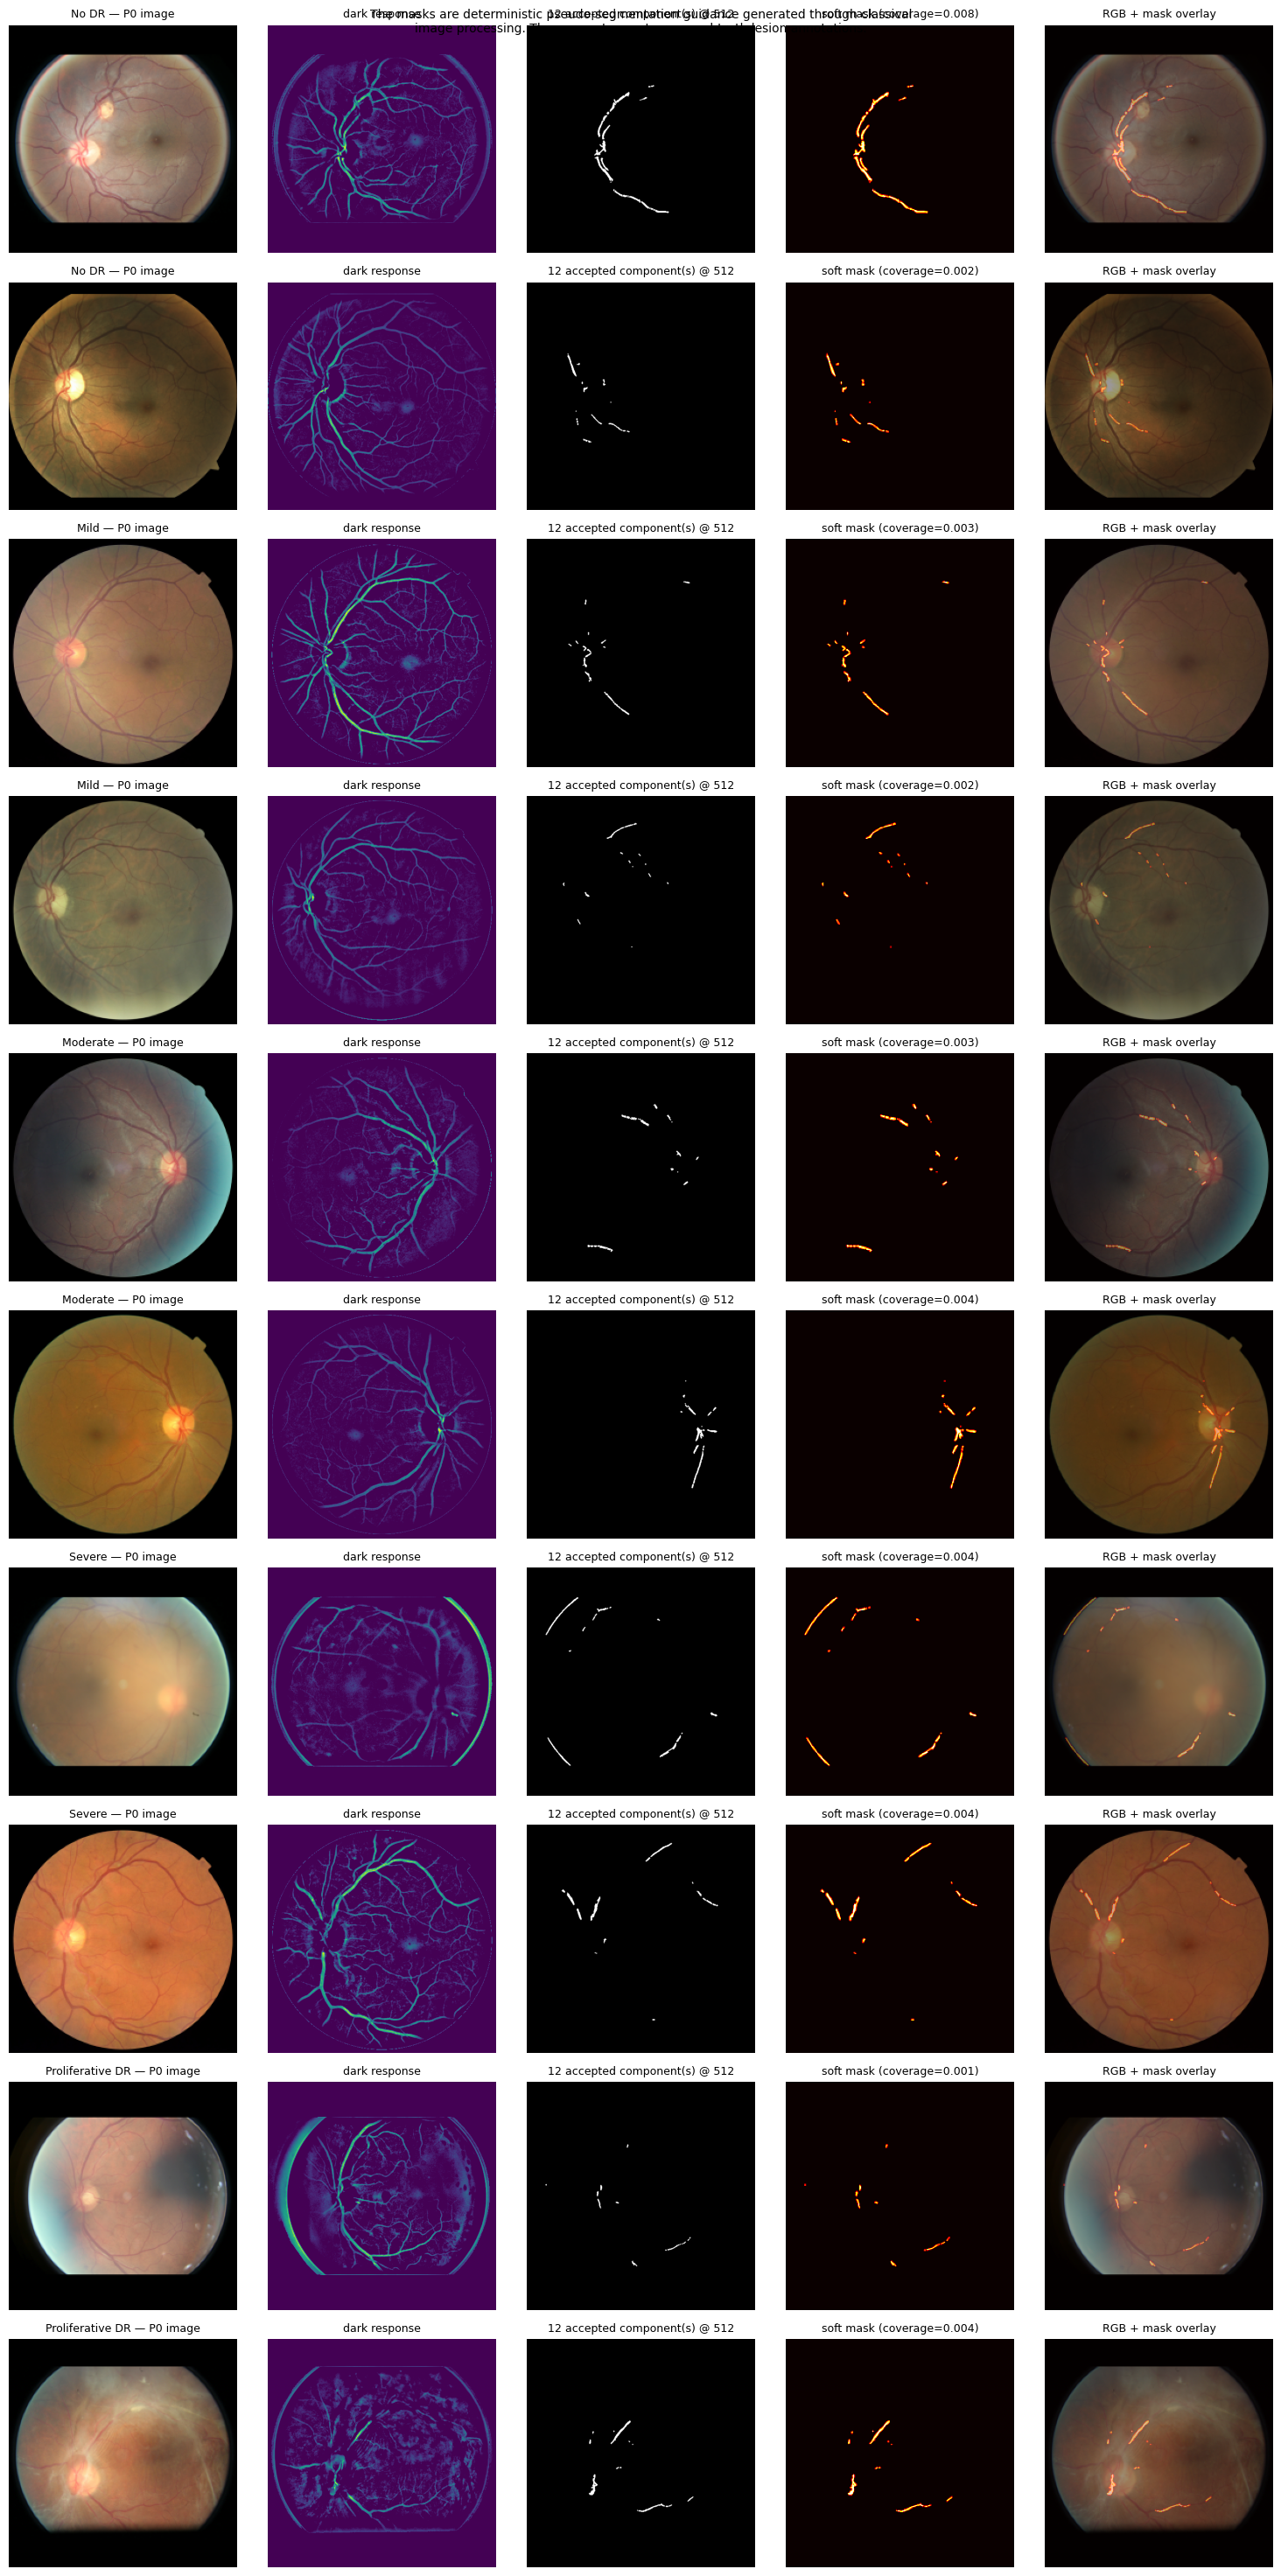

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M10_pseudo_segmentation_guidance/pseudo_mask_examples.png


In [10]:
def _generate_pseudo_segmentation_debug(image_rgb_full: np.ndarray) -> dict:
    """Same pipeline as generate_pseudo_segmentation_mask(), but also returns the
    intermediate dark-response and binary-component images, for visualisation only -
    the main dataset/cache path never needs these intermediates."""
    detection_image = cv2.resize(
        image_rgb_full, (DETECTION_SIZE, DETECTION_SIZE), interpolation=cv2.INTER_AREA
    )
    green = detection_image[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
    enhanced_green = clahe.apply(green)
    background = cv2.GaussianBlur(enhanced_green, (0, 0), BACKGROUND_SIGMA)
    dark_response = cv2.subtract(background, enhanced_green)

    gray = cv2.cvtColor(detection_image, cv2.COLOR_RGB2GRAY)
    field_mask = (gray > 10).astype(np.uint8)
    dark_response_masked = dark_response * field_mask

    mask_data = generate_pseudo_segmentation_mask(image_rgb_full)
    mask_data["detection_image"] = detection_image
    mask_data["dark_response"] = dark_response_masked
    return mask_data


examples_per_grade = 2
example_rows = []
for grade in range(NUM_CLASSES):
    grade_rows = train_df[train_df["level"] == grade].sample(
        n=min(examples_per_grade, (train_df["level"] == grade).sum()), random_state=SEED
    )
    example_rows.append(grade_rows)
example_df = pd.concat(example_rows, ignore_index=True)

fig, axes = plt.subplots(len(example_df), 5, figsize=(15, 3 * len(example_df)))

for row_idx, (_, row) in enumerate(example_df.iterrows()):
    image_full = preprocess_p0_full(row["filepath"])
    debug_data = _generate_pseudo_segmentation_debug(image_full)

    display_image = cv2.resize(image_full, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    pseudo_mask = debug_data["mask"]

    axes[row_idx, 0].imshow(display_image)
    axes[row_idx, 0].set_title(f"{CLASS_NAMES[row['level']]} — P0 image", fontsize=9)

    axes[row_idx, 1].imshow(debug_data["dark_response"], cmap="viridis")
    axes[row_idx, 1].set_title("dark response", fontsize=9)

    axes[row_idx, 2].imshow(
        debug_data["accepted_component_mask_512"],
        cmap="gray",
        vmin=0,
        vmax=255,
    )
    axes[row_idx, 2].set_title(
        f"{debug_data['num_components']} "
        "accepted component(s) @ 512",
        fontsize=9,
    )

    axes[row_idx, 3].imshow(pseudo_mask, cmap="hot", vmin=0, vmax=1)
    axes[row_idx, 3].set_title(f"soft mask (coverage={pseudo_mask.mean():.3f})", fontsize=9)

    axes[row_idx, 4].imshow(display_image)
    axes[row_idx, 4].imshow(pseudo_mask, cmap="hot", alpha=0.40, vmin=0, vmax=1)
    axes[row_idx, 4].set_title("RGB + mask overlay", fontsize=9)

    for col in range(5):
        axes[row_idx, col].axis("off")

fig.suptitle(
    "The masks are deterministic pseudo-segmentation guidance generated through classical\n"
    "image processing. They are not expert or ground-truth lesion annotations.",
    fontsize=10,
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pseudo_mask_examples.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'pseudo_mask_examples.png'}")

## 12. Dataset class and paired image+mask augmentation

The RGB image and the pseudo-mask must receive **exactly the same** horizontal flip,
rotation, translation and scale — otherwise the mask stops lining up with the lesions it was
generated from. `paired_train_transform()` samples one set of geometric parameters using
TorchVision's own `RandomAffine.get_params()` (the same sampling M07 used internally) and
applies it to both. Unlike M09, **both** the RGB image and the mask use **bilinear**
interpolation here — M09's guidance was a genuinely binary box map, where nearest-neighbour
was necessary to avoid inventing meaningless intermediate values at box edges, but M10's mask
is already a continuous soft occupancy map in `[0, 1]`, so bilinear interpolation is the
correct choice for it too. Colour jitter uses an actual `ColorJitter` module instance
(matching M07's parameter distribution and internal random operation order) and applies to
the RGB channels only; the mask channel is left in `[0, 1]` and untouched by colour jitter.
The two are concatenated into a single 4-channel tensor.

**Pseudo-mask caching.** The mask generator is deterministic and depends only on the fixed
P0 crop, so recomputing it inside `__getitem__` on every epoch would mean 600,000+ calls
across a full training run. `build_mask_cache()` runs the generator once per image up front
and writes each 224×224 soft mask to a small `.npy` file under `MASK_CACHE_DIR`; the dataset
then loads the cached array instead of recomputing it. The cache key includes the mask
parameters, so changing any of `DETECTION_SIZE` / `CLAHE_CLIP_LIMIT` /
`DARK_RESPONSE_PERCENTILE` / etc. in Section 3 naturally invalidates the old cache rather
than silently reusing stale masks. **Before actually running (not merely creating) this
notebook**, make sure `cache/maxvit_tiny/M10_pseudo_masks/` — or, better, `cache/` in
general — is listed in `.gitignore`.

In [11]:
MASK_PARAM_KEY = (
    f"det{DETECTION_SIZE}_clahe{CLAHE_CLIP_LIMIT}_bg{BACKGROUND_SIGMA}_"
    f"pct{DARK_RESPONSE_PERCENTILE}_area{MIN_COMPONENT_AREA}-{MAX_COMPONENT_AREA}_"
    f"ar{MAX_ASPECT_RATIO}_comp{MAX_CANDIDATE_COMPONENTS}"
)
PSEUDO_MASK_CACHE_DIR = MASK_CACHE_DIR / MASK_PARAM_KEY
PSEUDO_MASK_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _cache_path_for(image_name: str) -> Path:
    return PSEUDO_MASK_CACHE_DIR / f"{Path(image_name).stem}.npz"


def build_mask_cache(dataframe: pd.DataFrame) -> None:
    """Compute and cache the pseudo-mask for every image in dataframe that isn't
    already cached. Safe to re-run: already-cached images are skipped."""
    missing = [
        row for _, row in dataframe.iterrows()
        if not _cache_path_for(row["image"]).exists()
    ]
    if not missing:
        print(f"Mask cache already complete for {len(dataframe):,} images.")
        return

    for row in tqdm(missing, desc=f"caching pseudo-masks ({PSEUDO_MASK_CACHE_DIR.name})"):
        image_full = preprocess_p0_full(row["filepath"])
        mask_data = generate_pseudo_segmentation_mask(image_full)

        np.savez_compressed(
            _cache_path_for(row["image"]),
            mask=mask_data["mask"].astype(np.float32),
            num_components=np.int16(mask_data["num_components"]),
            mask_coverage=np.float32(mask_data["mask_coverage"]),
            threshold_value=np.float32(mask_data["threshold_value"]),
        )

    print(f"Cached {len(missing):,} new pseudo-masks -> {PSEUDO_MASK_CACHE_DIR}")


build_mask_cache(train_df)
build_mask_cache(val_df)

caching pseudo-masks (det512_clahe2.0_bg12.0_pct97.0_area3-350_ar4.0_comp12):   0%|          | 0/24586 [00:00<…

Cached 24,586 new pseudo-masks -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/cache/maxvit_tiny/M10_pseudo_masks/det512_clahe2.0_bg12.0_pct97.0_area3-350_ar4.0_comp12


caching pseudo-masks (det512_clahe2.0_bg12.0_pct97.0_area3-350_ar4.0_comp12):   0%|          | 0/5270 [00:00<?…

Cached 5,270 new pseudo-masks -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/cache/maxvit_tiny/M10_pseudo_masks/det512_clahe2.0_bg12.0_pct97.0_area3-350_ar4.0_comp12


In [12]:
colour_jitter = transforms.ColorJitter(
    brightness=BRIGHTNESS_JITTER,
    contrast=CONTRAST_JITTER,
    saturation=SATURATION_JITTER,
    hue=HUE_JITTER,
)


def paired_train_transform(rgb_image: Image.Image, mask_image: Image.Image):
    # Match M07 RandomHorizontalFlip behaviour.
    if torch.rand(1).item() < HORIZONTAL_FLIP_PROBABILITY:
        rgb_image = TF.hflip(rgb_image)
        mask_image = TF.hflip(mask_image)

    # Match M07 RandomAffine parameter sampling exactly.
    angle, translate, scale, shear = transforms.RandomAffine.get_params(
        degrees=[-ROTATION_DEGREES, ROTATION_DEGREES],
        translate=[TRANSLATE_FRACTION, TRANSLATE_FRACTION],
        scale_ranges=[SCALE_MIN, SCALE_MAX],
        shears=None,
        img_size=[IMAGE_SIZE, IMAGE_SIZE],
    )

    rgb_image = TF.affine(
        rgb_image, angle=angle, translate=translate, scale=scale, shear=shear,
        interpolation=transforms.InterpolationMode.BILINEAR, fill=0,
    )
    # M10's mask is a continuous soft occupancy map, not a binary box map (unlike M09), so
    # bilinear interpolation - not nearest-neighbour - is the correct choice here too.
    mask_image = TF.affine(
        mask_image, angle=angle, translate=translate, scale=scale, shear=shear,
        interpolation=transforms.InterpolationMode.BILINEAR, fill=0,
    )

    # Same ColorJitter distribution and random operation order as M07.
    rgb_image = colour_jitter(rgb_image)

    rgb_tensor = TF.normalize(TF.to_tensor(rgb_image), mean=list(VIT_MEAN), std=list(VIT_STD))
    mask_tensor = TF.to_tensor(mask_image).clamp(0, 1)

    return rgb_tensor, mask_tensor


def paired_eval_transform(rgb_image: Image.Image, mask_image: Image.Image):
    rgb_tensor = TF.normalize(TF.to_tensor(rgb_image), mean=list(VIT_MEAN), std=list(VIT_STD))
    mask_tensor = TF.to_tensor(mask_image).clamp(0, 1)
    return rgb_tensor, mask_tensor


class DRDatasetPseudoSegmentation(Dataset):
    """Returns a 4-channel (RGB + pseudo-mask) tensor, label and index. The mask generator
    never sees the label: generate_pseudo_segmentation_mask(image) only, not
    generate_pseudo_segmentation_mask(image, label). Masks are loaded from the pre-built
    cache (see above), not recomputed on every access."""

    def __init__(self, dataframe: pd.DataFrame, train_mode: bool = False):
        self.df = dataframe.reset_index(drop=True)
        self.train_mode = train_mode

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]

        image_full = preprocess_p0_full(row["filepath"])
        rgb_224 = cv2.resize(image_full, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

        cache_path = _cache_path_for(row["image"])
        if cache_path.exists():
            with np.load(cache_path) as cached:
                pseudo_mask = cached["mask"].astype(np.float32)
        else:
            # Fallback for any image the cache-build pass missed - computed on the fly and
            # cached for next time.
            mask_data = generate_pseudo_segmentation_mask(image_full)
            pseudo_mask = mask_data["mask"].astype(np.float32)

            np.savez_compressed(
                cache_path,
                mask=pseudo_mask,
                num_components=np.int16(mask_data["num_components"]),
                mask_coverage=np.float32(mask_data["mask_coverage"]),
                threshold_value=np.float32(mask_data["threshold_value"]),
            )

        rgb_image = Image.fromarray(rgb_224)
        mask_image = Image.fromarray((np.clip(pseudo_mask, 0, 1) * 255).astype(np.uint8))

        if self.train_mode:
            rgb_tensor, mask_tensor = paired_train_transform(rgb_image, mask_image)
        else:
            rgb_tensor, mask_tensor = paired_eval_transform(rgb_image, mask_image)

        model_input = torch.cat([rgb_tensor, mask_tensor], dim=0)
        assert model_input.shape == (INPUT_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)

        label = int(row["level"])
        return model_input, label, index


train_ds = DRDatasetPseudoSegmentation(train_df, train_mode=True)
val_ds = DRDatasetPseudoSegmentation(val_df, train_mode=False)

print(f"train_ds: {len(train_ds):,} | val_ds: {len(val_ds):,}")

train_ds: 24,586 | val_ds: 5,270


## 13. DataLoaders

Ordinary shuffling, no `WeightedRandomSampler` — identical to M07. Validation uses
`shuffle=False` and the deterministic eval transform (no augmentation, so RGB/guidance
alignment is trivially exact there).

In [13]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 769 | Val batches: 165


## 14. Class weights and ordinal-aware loss

Exactly M07's loss, unmodified: clipped class-weighted cross-entropy plus a normalised
expected squared grade-distance penalty (weight 0.5).

In [14]:
class OrdinalPenalisedLoss(nn.Module):
    """Clipped weighted CE plus normalised expected squared grade distance (unchanged from M07)."""

    def __init__(
        self,
        num_classes: int = NUM_CLASSES,
        ordinal_weight: float = ORDINAL_PENALTY_WEIGHT,
        class_weights: torch.Tensor = None,
        label_smoothing: float = 0.0,
    ):
        super().__init__()
        self.ordinal_weight = ordinal_weight
        self.num_classes = num_classes
        self.max_squared_distance = float((num_classes - 1) ** 2)

        self.cross_entropy = nn.CrossEntropyLoss(
            weight=class_weights, label_smoothing=label_smoothing,
        )
        self.register_buffer("grade_values", torch.arange(num_classes, dtype=torch.float32))

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = self.cross_entropy(logits, targets)

        probabilities = F.softmax(logits, dim=1)
        target_grades = targets.to(dtype=probabilities.dtype).unsqueeze(1)
        squared_distances = (self.grade_values.unsqueeze(0) - target_grades).pow(2)
        normalised_distances = squared_distances / self.max_squared_distance
        ordinal_loss = (probabilities * normalised_distances).sum(dim=1).mean()

        return ce_loss + self.ordinal_weight * ordinal_loss


raw_weights = compute_class_weight(
    class_weight=CLASS_WEIGHT_METHOD,
    classes=np.arange(NUM_CLASSES),
    y=train_df["level"].to_numpy(),
)
clipped_weights = np.clip(raw_weights, CLASS_WEIGHT_CLIP_MIN, CLASS_WEIGHT_CLIP_MAX)
class_weights = torch.tensor(clipped_weights, dtype=torch.float32, device=device)

criterion = OrdinalPenalisedLoss(
    num_classes=NUM_CLASSES,
    ordinal_weight=ORDINAL_PENALTY_WEIGHT,
    class_weights=class_weights,
    label_smoothing=LABEL_SMOOTHING,
).to(device)
LOSS_FUNCTION_LABEL = "clipped_weighted_ce_plus_normalised_expected_squared_ordinal_penalty"

print("Loss: clipped weighted CE + 0.5 x normalised ordinal penalty (unchanged from M07)")
print("Raw balanced weights:", np.round(raw_weights, 3))
print("Clipped weights:", np.round(clipped_weights, 3))

Loss: clipped weighted CE + 0.5 x normalised ordinal penalty (unchanged from M07)
Raw balanced weights: [0.272 2.877 1.33  8.061 9.699]
Clipped weights: [0.5  2.5  1.33 2.5  2.5 ]


## 15. Four-channel MaxViT model

`timm` adapts the pretrained first-convolution weights to accept four channels. The exact
adaptation is determined by the installed `timm` implementation. The fourth channel has not
been pretrained on retinal lesion guidance, so its usefulness must be learned during M10
fine-tuning. **M10 begins from the pretrained ImageNet MaxViT model — it does not load M07's
or M09's trained checkpoint.**

The dummy forward test below deliberately runs in `eval()` mode. MaxViT's MBConv blocks
contain real BatchNorm layers, and this shape test uses two all-zero images — passing that
through the model in `train()` mode would update BatchNorm's running statistics with a
degenerate, uninformative
input before any real training has happened, contaminating the controlled comparison with
M07 (which never ran this dummy pass at all). The model's original mode is restored
immediately afterward.

In [15]:
def build_model(pretrained: bool = True) -> nn.Module:
    return timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=NUM_CLASSES,
        in_chans=INPUT_CHANNELS,
    ).to(device)


model = build_model(pretrained=True)
total_parameters = sum(p.numel() for p in model.parameters())

print(f"Model: {MODEL_NAME}  (in_chans={INPUT_CHANNELS})")
print(f"Total parameters: {total_parameters:,}")

first_conv = next(
    module for module in model.modules() if isinstance(module, nn.Conv2d)
)
print("First convolution input channels:", first_conv.in_channels)
assert first_conv.in_channels == INPUT_CHANNELS

dummy = torch.zeros(
    2,
    INPUT_CHANNELS,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=device,
)

# Use evaluation mode so the shape test does not alter any running
# normalisation statistics in the actual model that will be trained.
previous_training_mode = model.training
model.eval()

try:
    with torch.no_grad():
        output = model(dummy)
finally:
    model.train(previous_training_mode)

assert output.shape == (2, NUM_CLASSES)
print("Four-channel MaxViT forward test: PASSED")

Model: maxvit_tiny_tf_224.in1k  (in_chans=4)
Total parameters: 30,406,669
First convolution input channels: 4
Four-channel MaxViT forward test: PASSED


## 16. Optimiser and scheduler

Exactly M07's single-stage recipe: `AdamW`, 3-epoch linear warm-up, cosine decay after.

In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

warmup_scheduler = LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS,
)
cosine_scheduler = CosineAnnealingLR(
    optimizer, T_max=max(1, MAX_EPOCHS - WARMUP_EPOCHS),
)
scheduler = SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS],
)

SCHEDULER_CONFIG = {
    "name": "SequentialLR",
    "warmup_scheduler": "LinearLR",
    "warmup_start_factor": 0.1,
    "warmup_end_factor": 1.0,
    "warmup_epochs": WARMUP_EPOCHS,
    "main_scheduler": "CosineAnnealingLR",
}

print(f"Optimizer: AdamW(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: {WARMUP_EPOCHS}-epoch linear warm-up -> CosineAnnealingLR")

Optimizer: AdamW(lr=5e-05, weight_decay=0.05)
Scheduler: 3-epoch linear warm-up -> CosineAnnealingLR


## 17. Training and validation functions

Same structure as M07's `run_epoch()`, with two additions M07 did not have: raw logits are
collected alongside probabilities (needed later for temperature scaling in a possible M13),
and non-finite logits/loss are checked explicitly **before backpropagation** rather than only
being caught implicitly downstream.

In [17]:
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


def run_epoch(
    model: nn.Module,
    loader,
    optimizer=None,
    train_mode: bool = True,
    grad_clip: float = GRAD_CLIP,
):
    if train_mode and optimizer is None:
        raise ValueError("An optimizer must be supplied during training.")

    model.train() if train_mode else model.eval()

    total_loss = 0.0
    total_samples = 0
    all_labels, all_preds, all_probs, all_logits, all_indices = [], [], [], [], []

    description = "train" if train_mode else "eval"

    for images, labels, indices in tqdm(loader, leave=False, desc=description):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            with torch.autocast(device_type=device.type, enabled=use_amp):
                logits = model(images)

                if not torch.isfinite(logits).all():
                    raise RuntimeError("Non-finite logits detected.")

                loss = criterion(logits, labels)

                if not torch.isfinite(loss):
                    raise RuntimeError("Non-finite loss detected.")

        if train_mode:
            scaler.scale(loss).backward()
            if grad_clip > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

        probabilities = F.softmax(logits.detach(), dim=1)
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_preds.extend(probabilities.argmax(dim=1).cpu().tolist())
        all_labels.extend(labels.detach().cpu().tolist())
        all_probs.extend(probabilities.cpu().tolist())
        all_logits.extend(logits.detach().cpu().tolist())
        all_indices.extend(indices.cpu().tolist())

    if total_samples == 0:
        raise RuntimeError("The DataLoader produced no samples.")

    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    if not np.isfinite(epoch_qwk):
        raise RuntimeError("QWK became NaN or infinity during the epoch.")

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "qwk": epoch_qwk,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "logits": all_logits,
        "indices": all_indices,
    }


def checkpoint_improved(
    val_qwk: float, val_macro_f1: float, best_qwk: float, best_macro_f1: float,
    tolerance: float = QWK_TOLERANCE,
) -> bool:
    """Validation QWK primary, validation macro-F1 tie-break."""
    if val_qwk > best_qwk + tolerance:
        return True
    if abs(val_qwk - best_qwk) <= tolerance and val_macro_f1 > best_macro_f1:
        return True
    return False

## 18. Early-stopping training loop

Identical structure and checkpoint rule to M07. `training_history.csv` is re-saved after
every epoch.

In [18]:
history = []
best_qwk = -1.0
best_macro_f1 = -1.0
patience_left = EARLY_STOPPING_PATIENCE

print("=" * 60)
print(f"  {RUN_NAME}")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8} {'Val F1':>8}")
print("-" * 60)

for epoch in range(1, MAX_EPOCHS + 1):
    lr_used = optimizer.param_groups[0]["lr"]

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer, train_mode=True)
    val_metrics = run_epoch(model, val_loader, train_mode=False)
    scheduler.step()

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "val_qwk": val_metrics["qwk"],
        "learning_rate": lr_used,
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(LOG_DIR / "training_history.csv", index=False)

    marker = ""
    if checkpoint_improved(val_metrics["qwk"], val_metrics["macro_f1"], best_qwk, best_macro_f1):
        best_qwk = val_metrics["qwk"]
        best_macro_f1 = val_metrics["macro_f1"]
        patience_left = EARLY_STOPPING_PATIENCE
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            BEST_CHECKPOINT_PATH,
        )
        marker = "  [best]"
    else:
        patience_left -= 1

    print(
        f"{epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f} {val_metrics['macro_f1']:>8.4f}"
        f"{marker}"
    )

    if patience_left <= 0:
        print(f"Early stopping at epoch {epoch}.")
        break

print(f"\nBest val QWK = {best_qwk:.4f} (macro-F1 = {best_macro_f1:.4f}) -> {BEST_CHECKPOINT_PATH.name}")

  M10_pseudo_segmentation_guidance
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK   Val F1
------------------------------------------------------------


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

1            1.3690   0.1960     1.1996   0.4561   0.2919  [best]


train:   0%|          | 0/769 [00:00<?, ?it/s]

...

eval:   0%|          | 0/165 [00:00<?, ?it/s]

12           0.2593   0.9117     1.7564   0.7134   0.5283


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

13           0.2035   0.9284     1.8106   0.7004   0.5256
Early stopping at epoch 13.

Best val QWK = 0.7523 (macro-F1 = 0.5422) -> best.pt


## 19. Training curves

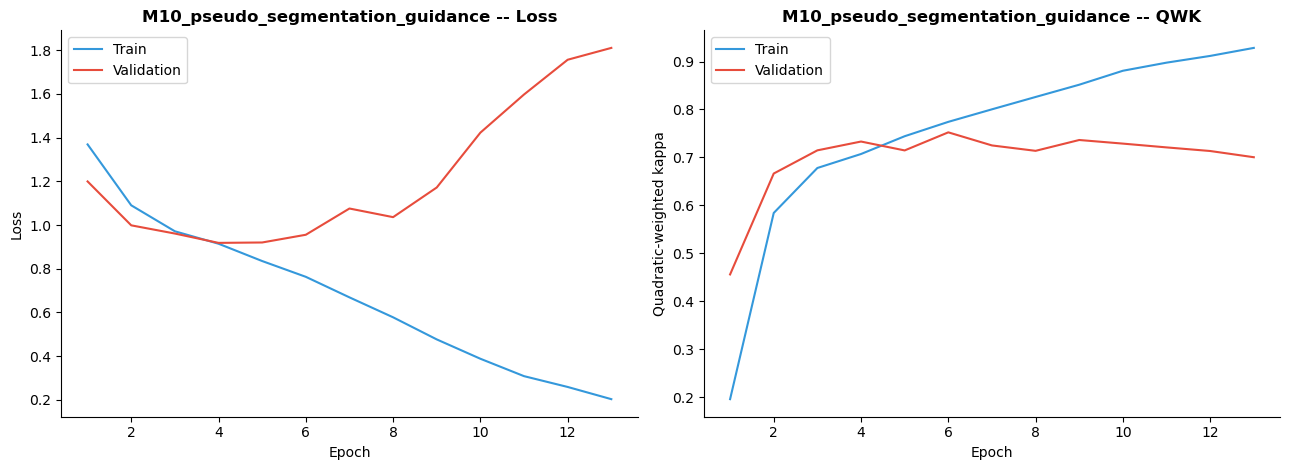

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M10_pseudo_segmentation_guidance/training_curves.png


In [19]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train", color="#3498DB")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation", color="#E74C3C")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"{RUN_NAME} -- Loss", fontweight="bold")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(history_df["epoch"], history_df["train_qwk"], label="Train", color="#3498DB")
axes[1].plot(history_df["epoch"], history_df["val_qwk"], label="Validation", color="#E74C3C")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Quadratic-weighted kappa")
axes[1].set_title(f"{RUN_NAME} -- QWK", fontweight="bold")
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_curves.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'training_curves.png'}")

## 20. Validation metrics and confusion matrix

Best checkpoint reloaded fresh and re-evaluated on `val_loader` — not the internal test set.

In [20]:
best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)

eval_model = build_model(pretrained=False)
eval_model.load_state_dict(best_checkpoint["model_state"])

print(f"Loaded: {BEST_CHECKPOINT_PATH.name}")
print(f"epoch={best_checkpoint['epoch']}  val_qwk={best_checkpoint['val_qwk']:.4f}  "
      f"val_macro_f1={best_checkpoint['val_macro_f1']:.4f}")

final_val_metrics = run_epoch(eval_model, val_loader, train_mode=False)

val_macro_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"], average="macro", zero_division=0,
)
val_macro_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"], average="macro", zero_division=0,
)

print()
print("=" * 60)
print(f"  {RUN_NAME} -- VALIDATION RESULTS (best checkpoint)")
print("=" * 60)
print(f"  Val QWK               : {final_val_metrics['qwk']:.4f}")
print(f"  Val accuracy           : {final_val_metrics['accuracy']:.4f}")
print(f"  Val balanced accuracy  : {final_val_metrics['balanced_accuracy']:.4f}")
print(f"  Val macro F1           : {final_val_metrics['macro_f1']:.4f}")
print(f"  Val macro precision    : {val_macro_precision:.4f}")
print(f"  Val macro recall       : {val_macro_recall:.4f}")
print()
print(classification_report(
    final_val_metrics["labels"], final_val_metrics["preds"],
    labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES, digits=3, zero_division=0,
))

Loaded: best.pt
epoch=6  val_qwk=0.7523  val_macro_f1=0.5422


eval:   0%|          | 0/165 [00:00<?, ?it/s]


  M10_pseudo_segmentation_guidance -- VALIDATION RESULTS (best checkpoint)
  Val QWK               : 0.7523
  Val accuracy           : 0.8055
  Val balanced accuracy  : 0.5464
  Val macro F1           : 0.5422
  Val macro precision    : 0.5567
  Val macro recall       : 0.5464

                  precision    recall  f1-score   support

           No DR      0.873     0.945     0.908      3873
            Mild      0.184     0.090     0.121       368
        Moderate      0.676     0.522     0.590       800
          Severe      0.383     0.567     0.457       127
Proliferative DR      0.667     0.608     0.636       102

        accuracy                          0.806      5270
       macro avg      0.557     0.546     0.542      5270
    weighted avg      0.779     0.806     0.788      5270



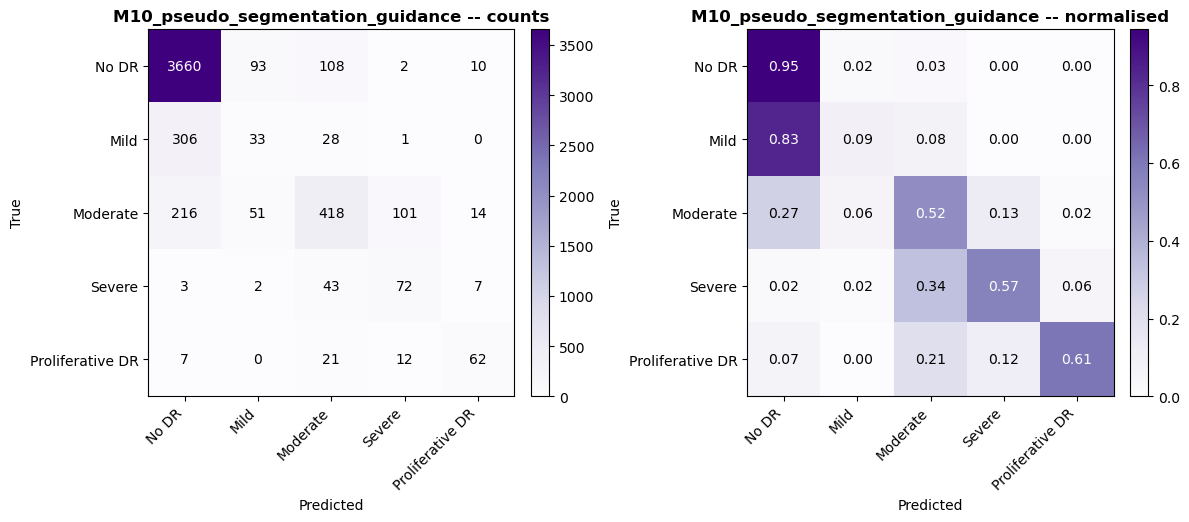

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M10_pseudo_segmentation_guidance/confusion_matrix.png


In [21]:
per_class_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_f1 = f1_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)

cm_counts = confusion_matrix(final_val_metrics["labels"], final_val_metrics["preds"])
cm_normalised = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, data, fmt, title in [
    (axes[0], cm_counts, "d", f"{RUN_NAME} -- counts"),
    (axes[1], cm_normalised, ".2f", f"{RUN_NAME} -- normalised"),
]:
    im = ax.imshow(data, interpolation="nearest", cmap="Purples")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")
    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                     color="white" if data[i, j] > thresh else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'confusion_matrix.png'}")

### Mild-DR and ordinal error diagnostics

Same combined diagnostic block used in M05-M09: Mild precision/recall/F1, Mild confusion
counts, and the full grade-error profile, so M10's fine-grained behaviour is directly
comparable to every prior notebook.

In [22]:
labels_array = np.asarray(final_val_metrics["labels"])
preds_array = np.asarray(final_val_metrics["preds"])

grade_error_array = preds_array - labels_array
absolute_grade_error = np.abs(grade_error_array)

mild_mask = labels_array == 1
moderate_mask = labels_array == 2

mild_precision = float(per_class_precision[1])
mild_recall = float(per_class_recall[1])
mild_f1 = float(per_class_f1[1])
moderate_f1 = float(per_class_f1[2])
severe_f1 = float(per_class_f1[3])

mild_correct = int(np.sum(mild_mask & (preds_array == 1)))
mild_to_no_dr = int(np.sum(mild_mask & (preds_array == 0)))
mild_to_moderate = int(np.sum(mild_mask & (preds_array == 2)))

mean_absolute_grade_error = float(absolute_grade_error.mean())
within_one_grade_accuracy = float((absolute_grade_error <= 1).mean())
adjacent_grade_error_rate = float((absolute_grade_error == 1).mean())
large_grade_error_rate = float((absolute_grade_error > 1).mean())

zero_to_four = int(np.sum((labels_array == 0) & (preds_array == 4)))
four_to_zero = int(np.sum((labels_array == 4) & (preds_array == 0)))

ordinal_error_distribution = {
    str(distance): int(np.sum(absolute_grade_error == distance))
    for distance in range(NUM_CLASSES)
}

print(f"Mild precision           : {mild_precision:.4f}")
print(f"Mild recall              : {mild_recall:.4f}")
print(f"Mild F1                  : {mild_f1:.4f}")
print(f"Mild correctly predicted : {mild_correct}")
print(f"Mild -> No DR errors     : {mild_to_no_dr}")
print(f"Mild -> Moderate errors  : {mild_to_moderate}")
print(f"Moderate F1              : {moderate_f1:.4f}")
print(f"Severe F1                : {severe_f1:.4f}")
print(f"Mean absolute grade error: {mean_absolute_grade_error:.4f}")
print(f"Within-one-grade accuracy: {within_one_grade_accuracy:.4f}")
print(f"Adjacent error rate      : {adjacent_grade_error_rate:.4f}")
print(f"Large grade-error rate   : {large_grade_error_rate:.4f}")
print(f"No DR -> PDR errors      : {zero_to_four}")
print(f"PDR -> No DR errors      : {four_to_zero}")

Mild precision           : 0.1844
Mild recall              : 0.0897
Mild F1                  : 0.1207
Mild correctly predicted : 33
Mild -> No DR errors     : 306
Mild -> Moderate errors  : 28
Moderate F1              : 0.5896
Severe F1                : 0.4571
Mean absolute grade error: 0.2748
Within-one-grade accuracy: 0.9271
Adjacent error rate      : 0.1216
Large grade-error rate   : 0.0729
No DR -> PDR errors      : 10
PDR -> No DR errors      : 7


## 21. Direct comparison with M07

Loads M07's **saved JSON results**, not its checkpoint. **The official ablation reference is
M07** — M10 seed 42 vs M07 seed 42. An additional *exploratory* M09-vs-M10 comparison follows
below, but it is secondary; M08 (a seed replicate of M07) is not a comparison target at all.

                Metric        M07        M10  Difference
                   QWK   0.761905   0.752320   -0.009585
              Macro-F1   0.551890   0.542177   -0.009713
     Balanced accuracy   0.550665   0.546390   -0.004275
        Mild precision   0.159483   0.184358    0.024875
           Mild recall   0.100543   0.089674   -0.010870
               Mild F1   0.123333   0.120658   -0.002675
           Moderate F1   0.575603   0.589563    0.013960
             Severe F1   0.489796   0.457143   -0.032653
         Mild -> No DR 306.000000 306.000000    0.000000
      Mild -> Moderate  25.000000  28.000000    3.000000
                   MAE   0.270588   0.274763    0.004175
Large-grade error rate   0.069639   0.072865    0.003226


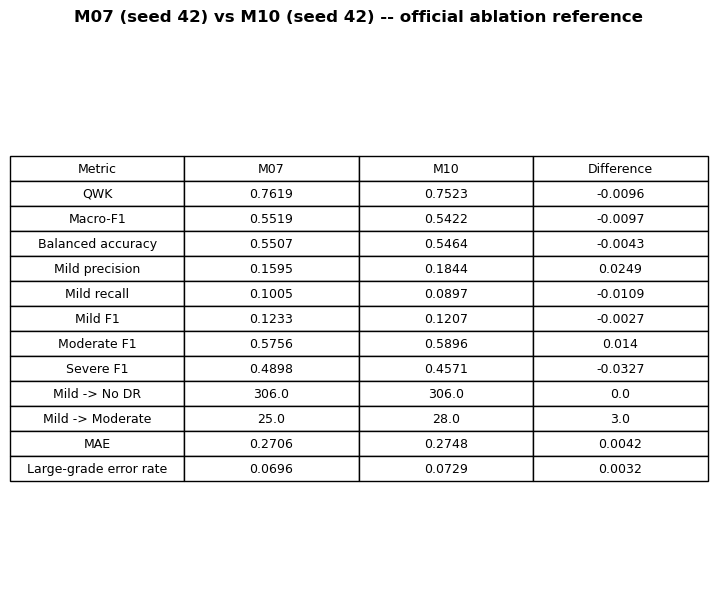

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M10_pseudo_segmentation_guidance/m07_m10_comparison.png


In [23]:
with open(M07_LOG_DIR / "best_metrics.json") as f:
    m07_best_metrics = json.load(f)
with open(M07_LOG_DIR / "validation_metrics.json") as f:
    m07_validation_metrics = json.load(f)

# M07's validation_metrics.json has no top-level "moderate_f1"/"severe_f1" keys - both are
# stored inside the per-class list (Moderate = grade 2, Severe = grade 3).
m07_moderate_f1 = float(m07_validation_metrics["per_class_f1"][2])
m07_severe_f1 = float(m07_validation_metrics["per_class_f1"][3])

comparison_rows = [
    ("QWK", m07_best_metrics["val_qwk"], final_val_metrics["qwk"]),
    ("Macro-F1", m07_best_metrics["val_macro_f1"], final_val_metrics["macro_f1"]),
    ("Balanced accuracy", m07_best_metrics["val_balanced_accuracy"], final_val_metrics["balanced_accuracy"]),
    ("Mild precision", m07_validation_metrics["mild_precision"], mild_precision),
    ("Mild recall", m07_validation_metrics["mild_recall"], mild_recall),
    ("Mild F1", m07_validation_metrics["mild_f1"], mild_f1),
    ("Moderate F1", m07_moderate_f1, moderate_f1),
    ("Severe F1", m07_severe_f1, severe_f1),
    ("Mild -> No DR", m07_validation_metrics["mild_to_no_dr"], mild_to_no_dr),
    ("Mild -> Moderate", m07_validation_metrics["mild_to_moderate"], mild_to_moderate),
    ("MAE", m07_validation_metrics["mean_absolute_grade_error"], mean_absolute_grade_error),
    ("Large-grade error rate", m07_validation_metrics["large_grade_error_rate"], large_grade_error_rate),
]

comparison_df = pd.DataFrame(comparison_rows, columns=["Metric", "M07", "M10"])
comparison_df["Difference"] = comparison_df["M10"] - comparison_df["M07"]

print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 0.5 * len(comparison_df) + 1))
ax.axis("off")
table = ax.table(
    cellText=comparison_df.round(4).astype(str).values,
    colLabels=comparison_df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
ax.set_title("M07 (seed 42) vs M10 (seed 42) -- official ablation reference", fontweight="bold", pad=20)

plt.savefig(FIGURE_DIR / "m07_m10_comparison.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'm07_m10_comparison.png'}")

comparison_df.to_csv(LOG_DIR / "m07_m10_comparison.csv", index=False)

### Exploratory comparison with M09

M09 (coarse bounding-region guidance) vs M10 (pixel-level pseudo-mask guidance) — both
already compared independently against the same M07 reference above. **This comparison is
secondary and exploratory; M07 remains the official ablation reference for M10, and no M09
result is used to tune M10 in any way.** If M09 hasn't finished yet when this cell runs, it
skips gracefully rather than failing.

                Metric        M09        M10  Difference
                   QWK   0.748463   0.752320    0.003857
              Macro-F1   0.555825   0.542177   -0.013648
     Balanced accuracy   0.531548   0.546390    0.014842
        Mild precision   0.197044   0.184358   -0.012687
           Mild recall   0.108696   0.089674   -0.019022
               Mild F1   0.140105   0.120658   -0.019447
           Moderate F1   0.622763   0.589563   -0.033200
             Severe F1   0.477733   0.457143   -0.020590
         Mild -> No DR 308.000000 306.000000   -2.000000
      Mild -> Moderate  20.000000  28.000000    8.000000
                   MAE   0.265275   0.274763    0.009488
Large-grade error rate   0.071347   0.072865    0.001518


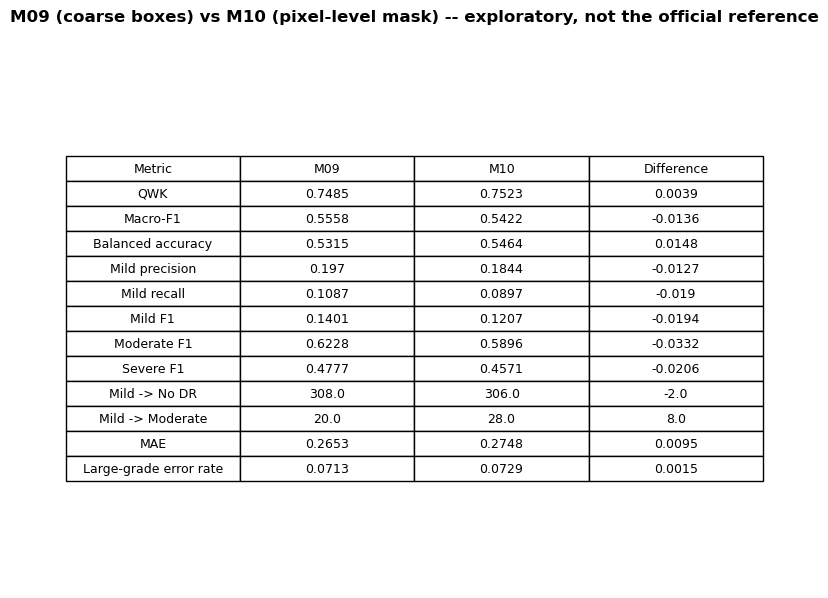

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M10_pseudo_segmentation_guidance/m09_m10_comparison.png


In [24]:
m09_metrics_path = M09_LOG_DIR / "validation_metrics.json"

if m09_metrics_path.exists():
    with open(M09_LOG_DIR / "best_metrics.json") as f:
        m09_best_metrics = json.load(f)
    with open(m09_metrics_path) as f:
        m09_validation_metrics = json.load(f)

    m09_moderate_f1 = float(m09_validation_metrics["per_class_f1"][2])
    m09_severe_f1 = float(m09_validation_metrics["per_class_f1"][3])

    m09_m10_rows = [
        ("QWK", m09_best_metrics["val_qwk"], final_val_metrics["qwk"]),
        ("Macro-F1", m09_best_metrics["val_macro_f1"], final_val_metrics["macro_f1"]),
        ("Balanced accuracy", m09_best_metrics["val_balanced_accuracy"], final_val_metrics["balanced_accuracy"]),
        ("Mild precision", m09_validation_metrics["mild_precision"], mild_precision),
        ("Mild recall", m09_validation_metrics["mild_recall"], mild_recall),
        ("Mild F1", m09_validation_metrics["mild_f1"], mild_f1),
        ("Moderate F1", m09_moderate_f1, moderate_f1),
        ("Severe F1", m09_severe_f1, severe_f1),
        ("Mild -> No DR", m09_validation_metrics["mild_to_no_dr"], mild_to_no_dr),
        ("Mild -> Moderate", m09_validation_metrics["mild_to_moderate"], mild_to_moderate),
        ("MAE", m09_validation_metrics["mean_absolute_grade_error"], mean_absolute_grade_error),
        ("Large-grade error rate", m09_validation_metrics["large_grade_error_rate"], large_grade_error_rate),
    ]

    m09_m10_df = pd.DataFrame(m09_m10_rows, columns=["Metric", "M09", "M10"])
    m09_m10_df["Difference"] = m09_m10_df["M10"] - m09_m10_df["M09"]

    print(m09_m10_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 0.5 * len(m09_m10_df) + 1))
    ax.axis("off")
    table = ax.table(
        cellText=m09_m10_df.round(4).astype(str).values,
        colLabels=m09_m10_df.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    ax.set_title(
        "M09 (coarse boxes) vs M10 (pixel-level mask) -- exploratory, not the official reference",
        fontweight="bold", pad=20,
    )

    plt.savefig(FIGURE_DIR / "m09_m10_comparison.png", dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {FIGURE_DIR / 'm09_m10_comparison.png'}")

    m09_m10_df.to_csv(LOG_DIR / "m09_m10_comparison.csv", index=False)
else:
    print(
        "M09 results are not available yet; "
        "comparison will be generated after M09 completes."
    )

## 22. Save logs and validation predictions

`mask_summary.csv` records the mask generator's behaviour across the full validation set
(component counts, coverage) — used both for the audit and for the extended prediction CSV
below. The prediction CSV includes raw logits (for a possible future M13 temperature-scaling
notebook), per-image mask statistics, and everything logged in M05-M09.

In [25]:
mask_summary_rows = []

for _, row in tqdm(
    val_df.iterrows(),
    total=len(val_df),
    desc="mask summary (validation)",
):
    cache_path = _cache_path_for(row["image"])

    if cache_path.exists():
        with np.load(cache_path) as cached:
            pseudo_mask = cached["mask"].astype(np.float32)
            num_components = int(cached["num_components"].item())
            mask_coverage = float(cached["mask_coverage"].item())
    else:
        image_full = preprocess_p0_full(row["filepath"])
        mask_data = generate_pseudo_segmentation_mask(image_full)

        pseudo_mask = mask_data["mask"]
        num_components = int(mask_data["num_components"])
        mask_coverage = float(mask_data["mask_coverage"])

    mask_summary_rows.append(
        {
            "image": row["image"],
            "num_candidate_components": num_components,
            "pseudo_mask_coverage": mask_coverage,
            "pseudo_mask_max": float(pseudo_mask.max()),
        }
    )

mask_summary_df = pd.DataFrame(mask_summary_rows)
mask_summary_df.to_csv(LOG_DIR / "mask_summary.csv", index=False)
print(f"Saved -> {LOG_DIR / 'mask_summary.csv'}")

mask summary (validation):   0%|          | 0/5270 [00:00<?, ?it/s]

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M10_pseudo_segmentation_guidance/mask_summary.csv


In [26]:
experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "run_name": RUN_NAME,
    "experiment_type": EXPERIMENT_TYPE,
    "predecessor_experiment": PREDECESSOR_EXPERIMENT,
    "experimental_change": "add_pixel_level_pseudo_segmentation_guidance_channel",
    "model_name": MODEL_NAME,
    "pretrained": True,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "input_channels": INPUT_CHANNELS,
    "rgb_channels": RGB_CHANNELS,
    "guidance_channels": GUIDANCE_CHANNELS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "warmup_epochs": WARMUP_EPOCHS,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "use_wrs": USE_WRS,
    "sampler": "shuffle",
    "loss_function": LOSS_FUNCTION_LABEL,
    "label_smoothing": LABEL_SMOOTHING,
    "class_weight_method": CLASS_WEIGHT_METHOD,
    "class_weight_clip_min": CLASS_WEIGHT_CLIP_MIN,
    "class_weight_clip_max": CLASS_WEIGHT_CLIP_MAX,
    "raw_class_weights": raw_weights.tolist(),
    "clipped_class_weights": clipped_weights.tolist(),
    "ordinal_penalty_type": "normalised_expected_squared_grade_distance",
    "ordinal_penalty_weight": ORDINAL_PENALTY_WEIGHT,
    "grad_clip": GRAD_CLIP,
    "qwk_tolerance": QWK_TOLERANCE,
    "selection_metric": "validation_qwk",
    "selection_tiebreak": "validation_macro_f1",
    "training_mode": TRAINING_MODE,
    "preprocessing": "P0",
    "scheduler": SCHEDULER_CONFIG,
    "normalisation_mean": list(VIT_MEAN),
    "normalisation_std": list(VIT_STD),
    "training_augmentation": {
        "policy": "safe_retinal_augmentation",
        "geometric_transform": "single_random_affine_paired_with_mask",
        "interpolation_rgb": "bilinear",
        "interpolation_mask": "bilinear",
        "horizontal_flip_probability": HORIZONTAL_FLIP_PROBABILITY,
        "rotation_degrees": ROTATION_DEGREES,
        "brightness_jitter": BRIGHTNESS_JITTER,
        "contrast_jitter": CONTRAST_JITTER,
        "saturation_jitter": SATURATION_JITTER,
        "hue_jitter": HUE_JITTER,
        "translation_fraction": TRANSLATE_FRACTION,
        "scale_min": SCALE_MIN,
        "scale_max": SCALE_MAX,
        "vertical_flip": False,
        "mixup": False,
        "random_erasing": False,
    },
    "guidance_type": "deterministic_pixel_level_pseudo_lesion_mask",
    "mask_representation": "soft_component_occupancy_map",
    "expert_annotations_used": False,
    "validation_labels_used_to_tune_mask_generator": False,
    "mask_generation_resolution": DETECTION_SIZE,
    "model_input_resolution": IMAGE_SIZE,
    "mask_generation_pipeline": {
        "method": "deterministic_classical_image_processing",
        "detection_size": DETECTION_SIZE,
        "clahe_clip_limit": CLAHE_CLIP_LIMIT,
        "clahe_tile_grid_size": list(CLAHE_TILE_GRID_SIZE),
        "background_sigma": BACKGROUND_SIGMA,
        "dark_response_percentile": DARK_RESPONSE_PERCENTILE,
        "min_component_area": MIN_COMPONENT_AREA,
        "max_component_area": MAX_COMPONENT_AREA,
        "max_aspect_ratio": MAX_ASPECT_RATIO,
        "max_candidate_components": MAX_CANDIDATE_COMPONENTS,
        "mask_representation": MASK_REPRESENTATION,
    },
    "total_parameters": total_parameters,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "num_workers": NUM_WORKERS,
    "mixed_precision": use_amp,
    "device": torch.cuda.get_device_name(0),
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "train_csv": str(TRAIN_CSV),
    "val_csv": str(VAL_CSV),
}

with open(LOG_DIR / "config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)
print(f"Saved -> {LOG_DIR / 'config.json'}")

best_metrics = {
    "epoch": best_checkpoint["epoch"],
    "val_loss": best_checkpoint["val_loss"],
    "val_accuracy": best_checkpoint["val_accuracy"],
    "val_balanced_accuracy": best_checkpoint["val_balanced_accuracy"],
    "val_macro_f1": best_checkpoint["val_macro_f1"],
    "val_qwk": best_checkpoint["val_qwk"],
}
with open(LOG_DIR / "best_metrics.json", "w") as f:
    json.dump(best_metrics, f, indent=2)
print(f"Saved -> {LOG_DIR / 'best_metrics.json'}")

validation_metrics = {
    "qwk": final_val_metrics["qwk"],
    "accuracy": final_val_metrics["accuracy"],
    "balanced_accuracy": final_val_metrics["balanced_accuracy"],
    "macro_f1": final_val_metrics["macro_f1"],
    "macro_precision": val_macro_precision,
    "macro_recall": val_macro_recall,
    "per_class_precision": per_class_precision.tolist(),
    "per_class_recall": per_class_recall.tolist(),
    "per_class_f1": per_class_f1.tolist(),
    "mild_precision": mild_precision,
    "mild_recall": mild_recall,
    "mild_f1": mild_f1,
    "moderate_f1": moderate_f1,
    "severe_f1": severe_f1,
    "mild_correct": mild_correct,
    "mild_to_no_dr": mild_to_no_dr,
    "mild_to_moderate": mild_to_moderate,
    "mean_absolute_grade_error": mean_absolute_grade_error,
    "within_one_grade_accuracy": within_one_grade_accuracy,
    "adjacent_grade_error_rate": adjacent_grade_error_rate,
    "large_grade_error_rate": large_grade_error_rate,
    "zero_to_four": zero_to_four,
    "four_to_zero": four_to_zero,
    "ordinal_error_distribution": ordinal_error_distribution,
}
with open(LOG_DIR / "validation_metrics.json", "w") as f:
    json.dump(validation_metrics, f, indent=2)
print(f"Saved -> {LOG_DIR / 'validation_metrics.json'}")

pred_rows = val_df.iloc[final_val_metrics["indices"]].reset_index(drop=True).copy()
pred_rows["true_label"] = final_val_metrics["labels"]
pred_rows["predicted_label"] = final_val_metrics["preds"]

logits_array = np.array(final_val_metrics["logits"])
probs_array = np.array(final_val_metrics["probs"])
for grade in range(NUM_CLASSES):
    pred_rows[f"logit_grade_{grade}"] = logits_array[:, grade]
for grade in range(NUM_CLASSES):
    pred_rows[f"prob_grade_{grade}"] = probs_array[:, grade]

pred_rows["confidence"] = probs_array.max(axis=1)
pred_rows["correct"] = pred_rows["true_label"] == pred_rows["predicted_label"]
pred_rows["grade_error"] = pred_rows["predicted_label"] - pred_rows["true_label"]
pred_rows["absolute_grade_error"] = pred_rows["grade_error"].abs()

assert pred_rows["image"].is_unique, (
    "Validation prediction image identifiers are not unique."
)
assert mask_summary_df["image"].is_unique, (
    "Mask summary image identifiers are not unique."
)

pred_rows = pred_rows.merge(
    mask_summary_df,
    on="image",
    how="left",
    validate="one_to_one",
)

if pred_rows[["num_candidate_components", "pseudo_mask_coverage"]].isna().any().any():
    raise RuntimeError(
        "Some validation predictions are missing mask statistics."
    )

prediction_columns = [
    "image", "patient_id", "eye", "true_label", "predicted_label",
    "logit_grade_0", "logit_grade_1", "logit_grade_2", "logit_grade_3", "logit_grade_4",
    "prob_grade_0", "prob_grade_1", "prob_grade_2", "prob_grade_3", "prob_grade_4",
    "confidence", "correct", "grade_error", "absolute_grade_error",
    "num_candidate_components", "pseudo_mask_coverage", "pseudo_mask_max",
]
pred_rows[prediction_columns].to_csv(LOG_DIR / "validation_predictions.csv", index=False)

print(f"Saved -> {LOG_DIR / 'validation_predictions.csv'}  ({len(pred_rows):,} rows)")
print()
print("training_history.csv was already saved incrementally during training.")

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M10_pseudo_segmentation_guidance/config.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M10_pseudo_segmentation_guidance/best_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M10_pseudo_segmentation_guidance/validation_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M10_pseudo_segmentation_guidance/validation_predictions.csv  (5,270 rows)

training_history.csv was already saved incrementally during training.


## 23. Experiment conclusion

M10 evaluated whether replacing M09's coarse filled candidate regions with more spatially
precise component-shaped pseudo-segmentation masks improved the M07 MaxViT model. M10
retained the complete M07 seed-42 training configuration and changed only the input from
three-channel RGB to four-channel RGB plus a deterministic pixel-level guidance mask.

The selected checkpoint occurred at epoch 6 and achieved a validation QWK of 0.7523,
macro-F1 of 0.5422 and balanced accuracy of 0.5464. M07 achieved a QWK of 0.7619,
macro-F1 of 0.5519 and balanced accuracy of 0.5507. M10 therefore reduced QWK by
0.0096, macro-F1 by 0.0097 and balanced accuracy by 0.0043. Under the predefined
QWK-first selection rule, M10 does not replace M07 as the strongest overall MaxViT
configuration.

The class-level effect was mixed. Mild precision increased from 0.1595 to 0.1844, but
Mild recall decreased from 0.1005 to 0.0897, producing a small Mild-F1 reduction from
0.1233 to 0.1207. Mild-to-No-DR errors remained unchanged at 306, while Mild-to-Moderate
errors increased from 25 to 28. Moderate F1 increased from 0.5756 to 0.5896, but Severe
F1 decreased from 0.4898 to 0.4571. Pixel-level guidance therefore helped one intermediate
grade slightly while harming other clinically important grades.

Ordinal performance also declined slightly. Mean absolute grade error increased from
0.2706 to 0.2748 and the large-grade error rate increased from 0.0696 to 0.0729.
Consequently, the pseudo-segmentation masks did not improve the primary ordinal behaviour
of the model.

Compared with M09's coarse candidate boxes, M10 improved QWK by 0.0039 and balanced
accuracy by 0.0148. However, it reduced macro-F1 by 0.0136, Mild F1 by 0.0194,
Moderate F1 by 0.0332 and Severe F1 by 0.0206. The more precise component-shaped
representation therefore did not consistently outperform the coarse-region representation.

The generated masks were extremely sparse, with mean coverage of approximately 0.0030
of the image and a 95th-percentile coverage of 0.0047. At the same time, every image in
the 300-image sanity sample reached the maximum of 12 accepted components. Visual
inspection suggests that many selected components corresponded to vessels, retinal borders
or other dark structures rather than clearly identifiable lesions. Because no expert lesion
annotations were available, these masks cannot be interpreted as medically verified lesion
segmentations.

Training performance continued to improve after epoch 6 while validation loss increased
and validation QWK declined, indicating increasing overfitting after the selected checkpoint.
Early stopping correctly preserved the epoch-6 model.

Overall, M10 provides a useful negative ablation: deterministic pixel-level
pseudo-segmentation guidance changed class-level behaviour but did not improve M07's
overall QWK, macro-F1 or Mild recognition. M07 remains the selected single-model reference.
M12 may still evaluate the pre-specified interaction between guidance components, but M10
alone provides no evidence that pixel-level pseudo-segmentation is beneficial.